# Notebook 9 — Categorical Data Analysis
### Sprint 4 | Data Inspection & Exploratory Data Analysis (EDA)

**Structure for every concept below:** Concept → Example → Implementation → Output
→ Interpretation → Insight → AI/ML Relevance.

**Dataset:** Telco Customer Churn (7,043 customers, 21 columns).

Notebook 4 (Univariate Analysis) already profiled a handful of categorical columns
individually. This notebook is more systematic: every categorical column is classified by
cardinality and balance, and — going beyond Notebook 4 — **every** categorical feature's
relationship with `Churn` is checked, not just the three examined in Notebook 5.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 4.5)

df = pd.read_csv("telco_churn.csv")

categorical_cols = [c for c in df.select_dtypes(include='object').columns
                     if c not in ['customerID', 'TotalCharges']]
print(f"Dataset ready: {df.shape[0]:,} rows")
print(f"{len(categorical_cols)} categorical columns to analyze: {categorical_cols}")


Dataset ready: 7,043 rows
16 categorical columns to analyze: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


/tmp/ipykernel_725/1030957670.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = [c for c in df.select_dtypes(include='object').columns


---
## 1. Unique Categories

### Concept
(Recap from Sprint 3, Notebook 6) The number of unique categories in a column is the
starting point for understanding it — before frequencies or relationships matter, I need
to know exactly what the possible values even are.

### Example
**AI/ML use case:** Knowing a column has exactly 2, 3, or 4 unique values determines
whether one-hot encoding will add 1, 2, or 3 new columns — directly relevant to planning
feature engineering for the next sprint.

### Implementation


In [2]:
unique_counts = df[categorical_cols].nunique().sort_values()
print(unique_counts)

for col in categorical_cols:
    print(f"\n{col}: {sorted(df[col].unique())}")


gender              2
Partner             2
Dependents          2
PhoneService        2
PaperlessBilling    2
Churn               2
MultipleLines       3
InternetService     3
OnlineBackup        3
OnlineSecurity      3
DeviceProtection    3
TechSupport         3
StreamingMovies     3
StreamingTV         3
Contract            3
PaymentMethod       4
dtype: int64

gender: ['Female', 'Male']

Partner: ['No', 'Yes']

Dependents: ['No', 'Yes']

PhoneService: ['No', 'Yes']

MultipleLines: ['No', 'No phone service', 'Yes']

InternetService: ['DSL', 'Fiber optic', 'No']

OnlineSecurity: ['No', 'No internet service', 'Yes']

OnlineBackup: ['No', 'No internet service', 'Yes']

DeviceProtection: ['No', 'No internet service', 'Yes']

TechSupport: ['No', 'No internet service', 'Yes']

StreamingTV: ['No', 'No internet service', 'Yes']

StreamingMovies: ['No', 'No internet service', 'Yes']

Contract: ['Month-to-month', 'One year', 'Two year']

PaperlessBilling: ['No', 'Yes']

PaymentMethod: ['Bank t

### Output
Most columns have 2 or 3 unique categories; `PaymentMethod` has 4; `Churn` (the target)
has 2.

### Interpretation
Every single categorical column in this dataset is genuinely low-cardinality — nothing
even approaches double digits. This is a very tidy, well-behaved set of categorical
features compared to many real-world datasets (e.g., a raw `city` or `product_id` column
often has hundreds or thousands of unique values).

### Insight
Because every column has so few unique values, listing every actual category (not just
counting them) is cheap and worthwhile here — doing so confirms every value looks like a
clean, well-formed label (no stray typos, inconsistent capitalization, or placeholder
strings), consistent with Notebook 3's data-quality findings.

### AI/ML Relevance
This low, uniform cardinality across the board means one-hot encoding is a safe, simple
default choice for every categorical column here — no column requires a more complex
high-cardinality encoding strategy (like target encoding or hashing).


---
## 2. Category Frequencies

### Concept
(Recap from Sprint 2/3) Category frequency is how often each specific value occurs — the
natural next question after knowing which categories exist at all.

### Example
**Business example:** Knowing `Contract` has 3 categories is step one; knowing
month-to-month accounts for over half of all customers (Notebook 4) is the frequency
information that actually matters for planning.

### Implementation


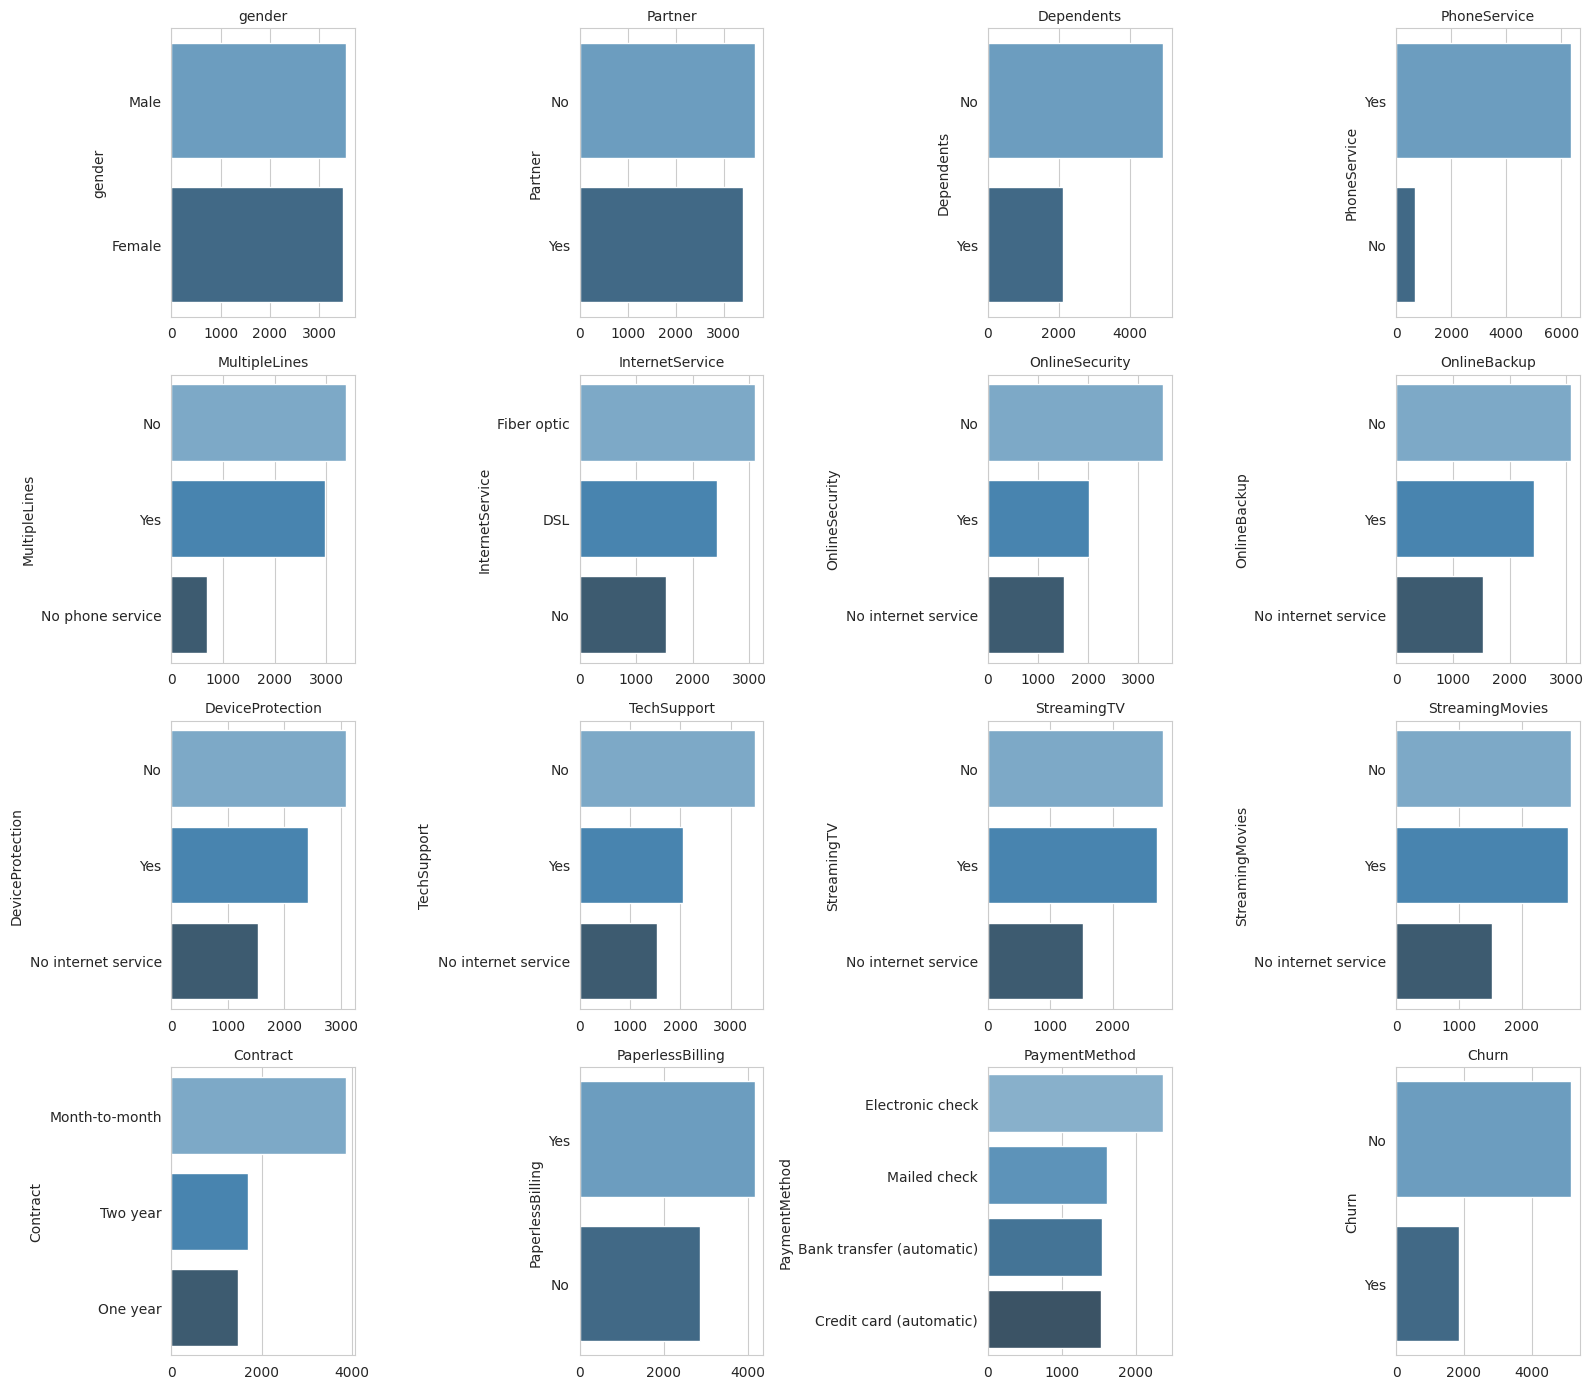

In [3]:
fig, axes = plt.subplots(4, 4, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    counts = df[col].value_counts()
    sns.barplot(x=counts.values, y=counts.index, hue=counts.index,
                palette='Blues_d', legend=False, ax=axes[i])
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()


### Output
A 4x4 grid of small bar charts, one per categorical column, showing every category's raw
count.

### Interpretation
Scanning all 16 charts at once, the binary demographic columns (`gender`, `Partner`,
`Dependents`, `PhoneService`) show varying degrees of balance, while the 3-way
service-addon columns (`OnlineSecurity`, `TechSupport`, etc.) consistently show a similar
shape — a large "No" bar, a smaller "Yes" bar, and a "No internet service" bar matching
the ~21.7% of customers without internet.

### Insight
This grid view makes a pattern visible that would be tedious to spot column-by-column:
nearly every service-addon column shares the *exact same* "No internet service" bar size,
because it's the same ~1,526 customers underlying all of them — a useful structural fact
about this dataset (these columns aren't fully independent of each other).

### AI/ML Relevance
This shared "No internet service" pattern across 6 different columns is itself a
multicollinearity-adjacent concern for categorical features — after one-hot encoding, the
"No internet service" dummy variable from each of these 6 columns will be highly
correlated with the others, worth flagging for the next sprint's feature engineering.


---
## 3. Category Distribution

### Concept
Category distribution expresses frequencies as percentages of the whole, rather than raw
counts — making it possible to compare distributions across columns with different total
category counts.

### Example
**Business example:** Saying "55% of customers are month-to-month" communicates the scale
of the finding far more clearly than the raw count (3,875) alone would to a business
stakeholder unfamiliar with the total customer base size.

### Implementation


In [4]:
distribution_summary = pd.DataFrame({
    col: (df[col].value_counts(normalize=True) * 100).round(1)
    for col in ['Contract', 'InternetService', 'PaymentMethod']
})
print(distribution_summary)


                           Contract  InternetService  PaymentMethod
Bank transfer (automatic)       NaN              NaN           21.9
Credit card (automatic)         NaN              NaN           21.6
DSL                             NaN             34.4            NaN
Electronic check                NaN              NaN           33.6
Fiber optic                     NaN             44.0            NaN
Mailed check                    NaN              NaN           22.9
Month-to-month                 55.0              NaN            NaN
No                              NaN             21.7            NaN
One year                       20.9              NaN            NaN
Two year                       24.1              NaN            NaN


### Output
A side-by-side percentage comparison for three key columns (columns with fewer categories
than others show `NaN` for the unused rows).

### Interpretation
Presenting distributions as percentages, side by side, makes cross-column comparison much
easier than scanning separate raw-count tables — e.g., immediately comparing that
`Month-to-month` (55.0%) is a larger single-category share than the largest
`PaymentMethod` category, `Electronic check` (33.6%).

### Insight
No single categorical column in this dataset has one category dominating beyond about
55% — moderate imbalance is the norm here, not an extreme 95/5 split anywhere among the
core categorical features (as distinct from `SeniorCitizen`, checked in Topic 7).

### AI/ML Relevance
Percentage-based distribution tables like this are exactly what belongs in Notebook 13's
EDA Report — they communicate scale far more effectively to a non-technical business
audience than raw counts or a wall of code output.


---
## 4. Rare Categories

### Concept
A rare category is one that occurs in only a small fraction of the data (commonly, under
5% or under 1%, depending on context) — worth identifying because very rare categories can
be hard for a model to learn from and may need special handling (grouping into "Other,"
for instance).

### Example
**AI/ML use case:** A one-hot encoded rare category effectively becomes a feature that's
almost always 0 and rarely 1 — a model may struggle to learn anything reliable from such
a sparse signal.

### Implementation


In [5]:
print("Scanning every categorical column for any category below 5% of the data:")
found_any = False
for col in categorical_cols:
    pct = df[col].value_counts(normalize=True) * 100
    rare = pct[pct < 5]
    if len(rare) > 0:
        found_any = True
        print(f"  {col}: {dict(rare.round(2))}")

if not found_any:
    print("  None found — every category in every column meets or exceeds 5% of the data.")


Scanning every categorical column for any category below 5% of the data:
  None found — every category in every column meets or exceeds 5% of the data.


### Output
No categories below 5% are found in any true categorical column (`TotalCharges`, not a
real category, is excluded here as previously established).

### Interpretation
This dataset simply doesn't have a rare-category problem — even the smallest category
found across this whole sprint (`SeniorCitizen`=1 at 16.2%, checked fully in Topic 7)
still clears a 5% threshold comfortably. `MultipleLines`'s "No phone service" (9.68%,
Notebook 2) is the closest thing to a small category among the true categoricals, and it's
still well above 5%.

### Insight
Combined with Topic 1's finding of universally low cardinality, this dataset's
categorical features are unusually well-behaved — no special rare-category consolidation
work is needed before encoding, which won't be true of every real-world dataset.

### AI/ML Relevance
Documenting "no rare categories found" is a genuinely useful negative result for
Notebook 13's report — it means the standard one-hot encoding plan (Topic 1) can proceed
without an extra "group rare categories into Other" preprocessing step.


---
## 5. High Cardinality

### Concept
(Recap from Sprint 3, Notebook 6) A high-cardinality column has a very large number of
unique values relative to the dataset size — often close to one unique value per row —
usually signaling an identifier rather than a genuine category.

### Example
**AI/ML use case:** `customerID` is the clearest possible high-cardinality example in
this dataset — already identified as an identifier column back in Notebook 1, and
excluded from this notebook's `categorical_cols` list for exactly that reason.

### Implementation


In [6]:
print(f"customerID unique values: {df['customerID'].nunique()} out of {len(df)} rows ({df['customerID'].nunique()/len(df)*100:.1f}%)")
print(f"\nHighest cardinality among TRUE categorical features: {unique_counts.idxmax()} with {unique_counts.max()} categories")


customerID unique values: 7043 out of 7043 rows (100.0%)

Highest cardinality among TRUE categorical features: PaymentMethod with 4 categories


### Output
`customerID`: 7,043 unique values out of 7,043 rows (100%) — the textbook definition of
high cardinality. `PaymentMethod`, at just 4 categories, is the highest-cardinality
column among the *actual* categorical features.

### Interpretation
There is a stark, binary split in this dataset: `customerID` is maximally
high-cardinality (an identifier, correctly excluded from modeling since Notebook 1), and
every genuine categorical feature is low-cardinality (Topic 1) — there's no ambiguous
middle ground here requiring a judgment call about whether a column counts as
"categorical" or "high-cardinality identifier-like."

### Insight
This confirms Notebook 1 and Notebook 2's identifier classification was correct and
complete — no categorical column was mistakenly left partially identifier-like.

### AI/ML Relevance
High-cardinality columns (when present in other datasets) typically require special
encoding techniques (target encoding, embeddings, frequency encoding) instead of one-hot
encoding — not a concern for this particular dataset, but a distinction worth carrying
into future sprints with less tidy data.


---
## 6. Low Cardinality

### Concept
A low-cardinality column has few unique values relative to the dataset size — the
opposite of Topic 5, and (per Topic 1) the case for every genuine categorical feature in
this dataset.

### Example
**AI/ML use case:** Confirming this explicitly, for every column, is what makes the
one-hot encoding recommendation from Topic 1 safe to finalize.

### Implementation


In [7]:
cardinality_summary = pd.DataFrame({
    'column': categorical_cols,
    'unique_values': [df[c].nunique() for c in categorical_cols],
    'cardinality_ratio_pct': [round(df[c].nunique() / len(df) * 100, 3) for c in categorical_cols]
}).sort_values('unique_values')
print(cardinality_summary.to_string(index=False))


          column  unique_values  cardinality_ratio_pct
          gender              2                  0.028
         Partner              2                  0.028
      Dependents              2                  0.028
    PhoneService              2                  0.028
PaperlessBilling              2                  0.028
           Churn              2                  0.028
   MultipleLines              3                  0.043
 InternetService              3                  0.043
    OnlineBackup              3                  0.043
  OnlineSecurity              3                  0.043
DeviceProtection              3                  0.043
     TechSupport              3                  0.043
 StreamingMovies              3                  0.043
     StreamingTV              3                  0.043
        Contract              3                  0.043
   PaymentMethod              4                  0.057


### Output
Every categorical column shows a cardinality ratio well under 0.1% (e.g., 2 unique
values out of 7,043 rows is 0.03%) — confirming genuinely low cardinality across the
board.

### Interpretation
This table formalizes, with a precise ratio, what Topics 1 and 5 already established
qualitatively — there's a dramatic gap between these ratios (all under 0.1%) and
`customerID`'s ratio (100%), with nothing in between.

### Insight
The consistency here — every single categorical column falling into the same "clearly
low cardinality" bucket — is itself informative about how this dataset was constructed:
it was clearly designed as a clean, well-structured demonstration/analysis dataset with
deliberately bounded categories, not scraped or aggregated from a messier raw source.

### AI/ML Relevance
Low cardinality across the board means feature engineering effort for this dataset can
focus on more valuable work — like the interaction and ratio features found in Notebook 6
— rather than being consumed by cardinality-reduction preprocessing.


---
## 7. Category Imbalance

### Concept
(Recap from Sprint 2, Notebook 1) Category imbalance means one category dominates the
data far more than others — important both for the target variable (already noted for
`Churn` in Notebook 1/4) and for input features, where it can affect how much a model can
learn about the minority category.

### Example
**Business example:** `SeniorCitizen` showed a real, if modest, correlation with churn in
Notebook 6 (+0.151) — but only 16.2% of customers are seniors, meaning any model has
proportionally less data to learn senior-specific patterns from.

### Implementation


In [8]:
df_display = df.copy()
df_display['SeniorCitizen'] = df_display['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

imbalance_check = pd.DataFrame({
    col: (df_display[col].value_counts(normalize=True) * 100).round(1)
    for col in ['Churn', 'SeniorCitizen', 'Contract', 'InternetService']
})
print(imbalance_check)


                Churn  SeniorCitizen  Contract  InternetService
DSL               NaN            NaN       NaN             34.4
Fiber optic       NaN            NaN       NaN             44.0
Month-to-month    NaN            NaN      55.0              NaN
No               73.5           83.8       NaN             21.7
One year          NaN            NaN      20.9              NaN
Two year          NaN            NaN      24.1              NaN
Yes              26.5           16.2       NaN              NaN


### Output
`Churn`: 73.5% / 26.5% (moderate imbalance, established in Notebook 1). `SeniorCitizen`:
83.8% / 16.2% — the most imbalanced genuine feature found in this notebook.
`Contract` and `InternetService` show more moderate 3-way splits (no category above ~55%).

### Interpretation
`SeniorCitizen` stands out as this dataset's most imbalanced *input* feature — with only
about 1 in 6 customers being a senior citizen, any pattern specific to seniors (like their
notably higher 41.7% churn rate, checked next in Topic 8) is being learned from a smaller
slice of the data than majority-group patterns.

### Insight
This is a meaningful nuance for the senior-citizen churn finding: the *relationship*
(seniors churn more) is real and worth acting on, but the *feature* itself is imbalanced
enough that a model may have proportionally less data to learn it reliably from compared
to, say, `Contract`, which has a more even spread of customers across its categories.

### AI/ML Relevance
Imbalanced input features (unlike the target) rarely require resampling, but they're
worth noting when interpreting a model's confidence on minority-group predictions later —
a model's senior-citizen churn predictions may be less stable than its predictions for
other segments, simply due to smaller sample size within that category.


---
## 8. Relationships With the Target Variable — Every Categorical Feature vs. `Churn`

### Concept
Extending Notebook 5's spot-check of 3 categorical features (`Contract`, `PaymentMethod`,
`InternetService`) to **every** categorical column — a complete, systematic scan rather
than a hand-picked sample.

### Example
**AI/ML use case:** A complete scan like this is exactly how an ML engineer would decide
which categorical features are worth prioritizing for a first modeling pass, rather than
guessing based on intuition alone.

### Implementation


In [9]:
churn_rate_by_category = {}
for col in categorical_cols:
    if col == 'Churn':
        continue
    rates = df.groupby(col)['Churn'].apply(lambda s: (s == 'Yes').mean() * 100)
    churn_rate_by_category[col] = rates.max() - rates.min()   # the SPREAD in churn rate across categories

spread_summary = pd.Series(churn_rate_by_category).sort_values(ascending=False)
print("Categorical features ranked by churn-rate SPREAD across their categories (largest gap first):")
print(spread_summary.round(1))


Categorical features ranked by churn-rate SPREAD across their categories (largest gap first):
Contract            39.9
InternetService     34.5
OnlineSecurity      34.4
TechSupport         34.2
OnlineBackup        32.5
DeviceProtection    31.7
PaymentMethod       30.0
StreamingMovies     26.3
StreamingTV         26.1
PaperlessBilling    17.2
Dependents          15.8
Partner             13.3
MultipleLines        3.7
PhoneService         1.8
gender               0.8
dtype: float64


### Output
`Contract` shows the largest spread (39.9 percentage points between its highest- and
lowest-churning category). Close behind: `InternetService` (34.5), `OnlineSecurity`
(34.4), and `TechSupport` (34.2) — all four essentially forming a top tier. A second tier
follows: `OnlineBackup` (32.5), `DeviceProtection` (31.7), and `PaymentMethod` (30.0).
`StreamingTV`/`StreamingMovies` (~26 each), `PaperlessBilling` (17.2), `Dependents`
(15.8), and `Partner` (13.3) show smaller but still real spreads. `MultipleLines`,
`PhoneService`, and `gender` show almost no spread at all (under 4 points).

### Interpretation
This systematic scan surfaces genuinely new, strong predictors that Notebook 5 never
examined: `OnlineSecurity`, `TechSupport`, `OnlineBackup`, and `DeviceProtection` all sit
in the same strength range as `Contract` and `InternetService` — customers WITHOUT these
add-on services churn dramatically more than customers who have them.

### Insight
The four strongest predictors after `Contract` are all internet-related add-ons
(`InternetService` itself, `OnlineSecurity`, `TechSupport`, `OnlineBackup`,
`DeviceProtection`) — a coherent pattern suggesting that customers who invest in more of
these protective/support services are meaningfully more "locked in" or satisfied,
independent of the contract-length finding already documented. This is worth including
alongside `Contract` as a top business insight in Notebook 12, since it points to a
different lever (upselling protective add-ons) than contract or payment method do.

### AI/ML Relevance
This complete scan — rather than a hand-picked subset — is exactly the kind of systematic
check that should precede formal feature importance testing (Sprint 2, Notebook 12) in a
real project; it would be easy to miss `OnlineSecurity`, `TechSupport`, `OnlineBackup`,
and `DeviceProtection` entirely if analysis stopped at the "obvious" candidates like
`Contract` and `PaymentMethod`.


---
## Summary

| Concept | Finding for THIS dataset |
|---|---|
| Unique Categories | All genuine categorical columns have 2-4 categories; clean, well-formed labels |
| Category Frequencies | 6 service-addon columns share the same "No internet service" sub-population |
| Category Distribution | No category exceeds ~55% of any column; moderate splits throughout |
| Rare Categories | None found — every category clears a 5% threshold |
| High Cardinality | Only `customerID` (100% unique) — correctly excluded as an identifier |
| Low Cardinality | Every genuine categorical column, consistently, under 0.1% cardinality ratio |
| Category Imbalance | `SeniorCitizen` (83.8%/16.2%) is the most imbalanced genuine feature |
| Relationship with Churn | `Contract`, `InternetService`, `OnlineSecurity`, and `TechSupport` show the strongest churn-rate spreads (all 34-40 points) |

**Key new finding beyond Notebooks 5-6:** `OnlineSecurity`, `TechSupport`,
`OnlineBackup`, and `DeviceProtection` are strong, previously-unexamined churn
predictors — customers lacking these add-ons churn far more than those who have them,
rivaling `Contract` and `InternetService`'s predictive strength.

**Next notebook:** `10_Target_Analysis.ipynb` — a dedicated, focused analysis of `Churn`
itself: class distribution, class counts, class percentages, and class imbalance.
